# Assignment 2 — Task 2: Car Price Model Comparison

**Name:** Lin Htet Aung

This notebook extends Assignment 1's cleaned car data, train/test split, log-price target, and missing-value handling. It uses the from-scratch regression implementation developed for Task 1. The untouched test set is used only after cross-validation selects the best model.

## Step 1 — Load and clean the Assignment 1 data

The attached A1 sequence is reproduced exactly: remove CNG/LPG; ordinal-encode ownership; parse mileage, engine, and power; extract brand; remove torque and test-drive cars; delete rows missing mileage, engine, power, or seats; and finally remove duplicates after transformation.

In [1]:
from pathlib import Path
import os
os.environ['MLFLOW_DISABLE_AGENT_HINT'] = '1'
import joblib
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split

from run_task2_mlflow import (
    clean_data, build_grid, NUMERIC, CATEGORICAL, RANDOM_STATE
)

raw = pd.read_csv('../../data/Cars.csv')
data = clean_data(raw)
X = data[NUMERIC + CATEGORICAL]
y = np.log(data['selling_price'].astype(float))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print('Raw shape:', raw.shape)
print('Cleaned shape:', data.shape)
print('Training rows:', len(X_train), '| Test rows:', len(X_test))
display(data.head())
display(data[NUMERIC + CATEGORICAL].isna().sum().to_frame('missing'))

Raw shape: (8128, 13)
Cleaned shape: (6607, 12)
Training rows: 5285 | Test rows: 1322


,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.4,1248,74.0,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.7,1497,78.0,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.0,1396,90.0,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.1,1298,88.2,5.0


,missing
year,0
km_driven,0
owner,0
mileage,0
engine,0
max_power,0
seats,0
brand,0
fuel,0
seller_type,0


## Step 2 — Define the 144 configurations

The full factorial comparison is 4 model types × 2 momentum choices × 3 gradient methods × 2 initialization methods × 3 learning rates = **144 configurations**. Each configuration uses the same shuffled five-fold splits. Preprocessing is fitted independently inside each training fold to prevent information leakage.

In [2]:
configurations = build_grid()
print('Configurations:', len(configurations))
display(pd.DataFrame(configurations).head(12))
assert len(configurations) == 4 * 2 * 3 * 2 * 3 == 144

Configurations: 144


,model_type,polynomial,regularization,use_momentum,method,initialization,learning_rate
0,normal,False,normal,False,stochastic,zeros,0.0100
1,normal,False,normal,False,stochastic,zeros,0.0010
2,normal,False,normal,False,stochastic,zeros,0.0001
3,normal,False,normal,False,stochastic,xavier,0.0100
4,normal,False,normal,False,stochastic,xavier,0.0010
5,normal,False,normal,False,stochastic,xavier,0.0001
6,normal,False,normal,False,mini-batch,zeros,0.0100
7,normal,False,normal,False,mini-batch,zeros,0.0010
8,normal,False,normal,False,mini-batch,zeros,0.0001
9,normal,False,normal,False,mini-batch,xavier,0.0100


## Step 3 — Run and verify the MLflow experiment

`run_task2_mlflow.py` opens one MLflow run **before** evaluating each configuration. It logs all parameters, every fold's MSE/R², the mean cross-validation metrics, and their standard deviations. The code below uses the completed local database. Set `RUN_EXPERIMENT=True` only when all 144 configurations need to be regenerated.

In [3]:
RUN_EXPERIMENT = False
if RUN_EXPERIMENT:
    from run_task2_mlflow import main
    main()
else:
    print('Using the completed MLflow experiment artifacts.')

tracking_database = Path('mlflow_task2_a1.db').resolve()
mlflow.set_tracking_uri(f'sqlite:///{tracking_database}')
experiment = mlflow.get_experiment_by_name('A2 Task 2 - Based on A1 Car Price Notebook')
logged_runs = mlflow.search_runs([experiment.experiment_id], max_results=200)
print('MLflow experiment:', experiment.name)
print('Finished MLflow runs:', len(logged_runs))
assert len(logged_runs) == 144
assert set(logged_runs['status']) == {'FINISHED'}

Using the completed MLflow experiment artifacts.


MLflow experiment: A2 Task 2 - Based on A1 Car Price Notebook
Finished MLflow runs: 144


## Step 4 — Final comparison tables

The first table shows the strongest configurations. The factor-level table summarizes the average effect of each choice. The final table contains all 144 comparisons and is also saved as `task2_experiment_results.csv`. Higher R² and lower MSE are better.

In [4]:
results = pd.read_csv('task2_experiment_results.csv')
assert len(results) == 144
assert not results.duplicated(
    ['model_type', 'use_momentum', 'method', 'initialization', 'learning_rate']
).any()
print('Top 15 configurations:')
display(results.head(15).round(6))

factor_tables = []
for factor in ['model_type', 'use_momentum', 'method', 'initialization', 'learning_rate']:
    table = results.groupby(factor)[['cv_mse', 'cv_r2']].mean().reset_index()
    table.insert(0, 'factor', factor)
    table = table.rename(columns={factor: 'choice'})
    factor_tables.append(table)
factor_summary = pd.concat(factor_tables, ignore_index=True)
print('Average comparison by experimental factor:')
display(factor_summary.round(6))

Top 15 configurations:


,model_type,polynomial,regularization,use_momentum,method,initialization,learning_rate,cv_mse,cv_mse_std,cv_r2,cv_r2_std
0,polynomial,True,normal,False,stochastic,zeros,0.0010,0.060138,0.001556,0.893693,0.004543
1,polynomial,True,normal,True,stochastic,zeros,0.0001,0.060206,0.001508,0.893566,0.004653
2,polynomial,True,normal,True,stochastic,xavier,0.0001,0.060476,0.001501,0.893111,0.004112
3,polynomial,True,normal,False,stochastic,xavier,0.0010,0.060531,0.001372,0.893006,0.004171
4,normal,False,normal,False,stochastic,xavier,0.0010,0.067904,0.003963,0.880186,0.003222
5,normal,False,normal,True,stochastic,xavier,0.0001,0.067988,0.004133,0.880046,0.003494
6,ridge,False,ridge,False,stochastic,xavier,0.0010,0.067987,0.004010,0.880042,0.003289
7,normal,False,normal,False,stochastic,zeros,0.0010,0.068063,0.004222,0.879918,0.003657
8,ridge,False,ridge,True,stochastic,xavier,0.0001,0.068071,0.004178,0.879903,0.003558
9,normal,False,normal,True,stochastic,zeros,0.0001,0.068081,0.004230,0.879885,0.003687


Average comparison by experimental factor:


,factor,choice,cv_mse,cv_r2
0,model_type,lasso,0.260270,0.540362
1,model_type,normal,0.261494,0.538102
2,model_type,polynomial,0.500300,0.130305
3,model_type,ridge,0.260644,0.539656
4,use_momentum,False,0.301422,0.467302
5,use_momentum,True,0.339932,0.406911
6,method,batch,0.487609,0.138092
7,method,mini-batch,0.207298,0.633934
8,method,stochastic,0.267123,0.539293
9,initialization,xavier,0.377596,0.339051


In [5]:
with pd.option_context('display.max_rows', 144, 'display.max_columns', None):
    display(results.round(6))

,model_type,polynomial,regularization,use_momentum,method,initialization,learning_rate,cv_mse,cv_mse_std,cv_r2,cv_r2_std
0,polynomial,True,normal,False,stochastic,zeros,0.0010,0.060138,0.001556,0.893693,0.004543
1,polynomial,True,normal,True,stochastic,zeros,0.0001,0.060206,0.001508,0.893566,0.004653
2,polynomial,True,normal,True,stochastic,xavier,0.0001,0.060476,0.001501,0.893111,0.004112
3,polynomial,True,normal,False,stochastic,xavier,0.0010,0.060531,0.001372,0.893006,0.004171
4,normal,False,normal,False,stochastic,xavier,0.0010,0.067904,0.003963,0.880186,0.003222
5,normal,False,normal,True,stochastic,xavier,0.0001,0.067988,0.004133,0.880046,0.003494
6,ridge,False,ridge,False,stochastic,xavier,0.0010,0.067987,0.004010,0.880042,0.003289
7,normal,False,normal,False,stochastic,zeros,0.0010,0.068063,0.004222,0.879918,0.003657
8,ridge,False,ridge,True,stochastic,xavier,0.0001,0.068071,0.004178,0.879903,0.003558
9,normal,False,normal,True,stochastic,zeros,0.0001,0.068081,0.004230,0.879885,0.003687


## Step 5 — Captured MLflow evidence

### MLflow table of completed configuration runs

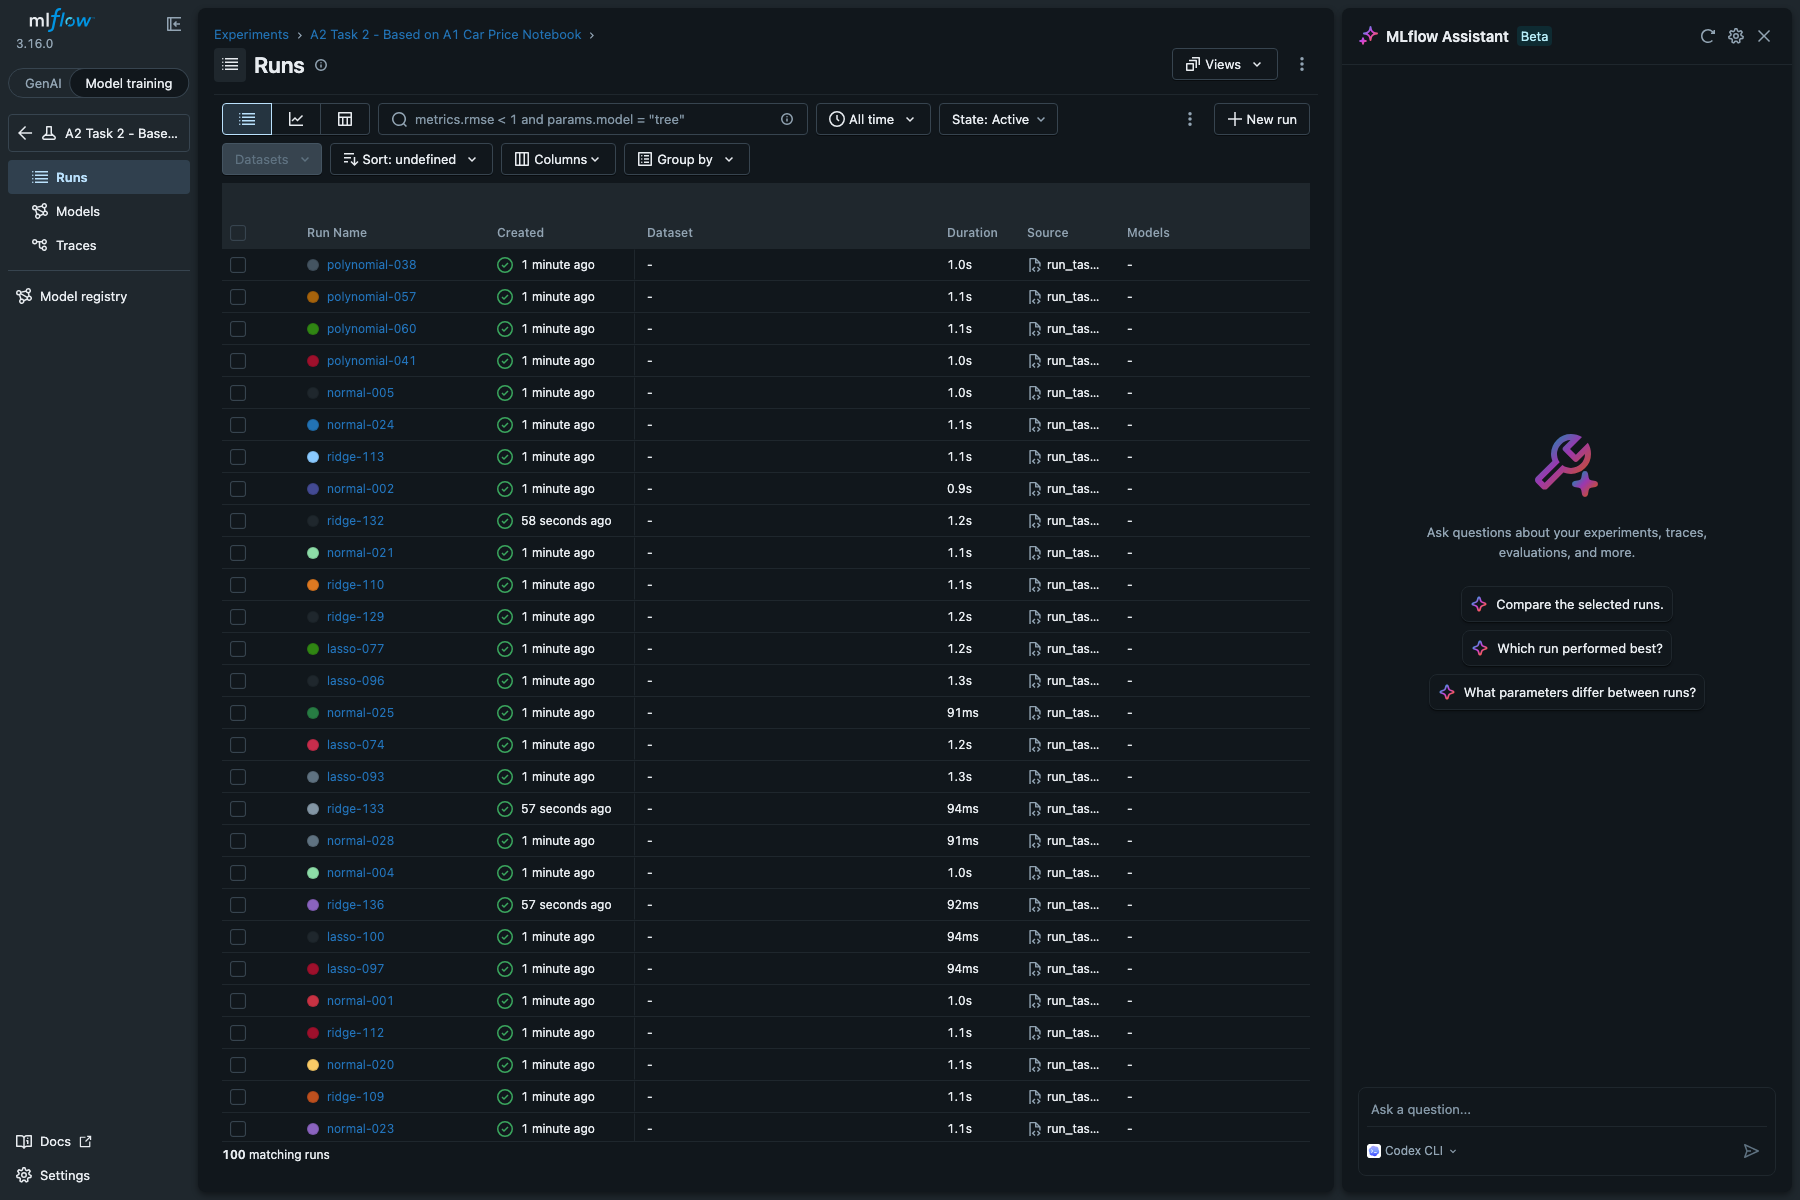

### MLflow parameters and metrics for the best run

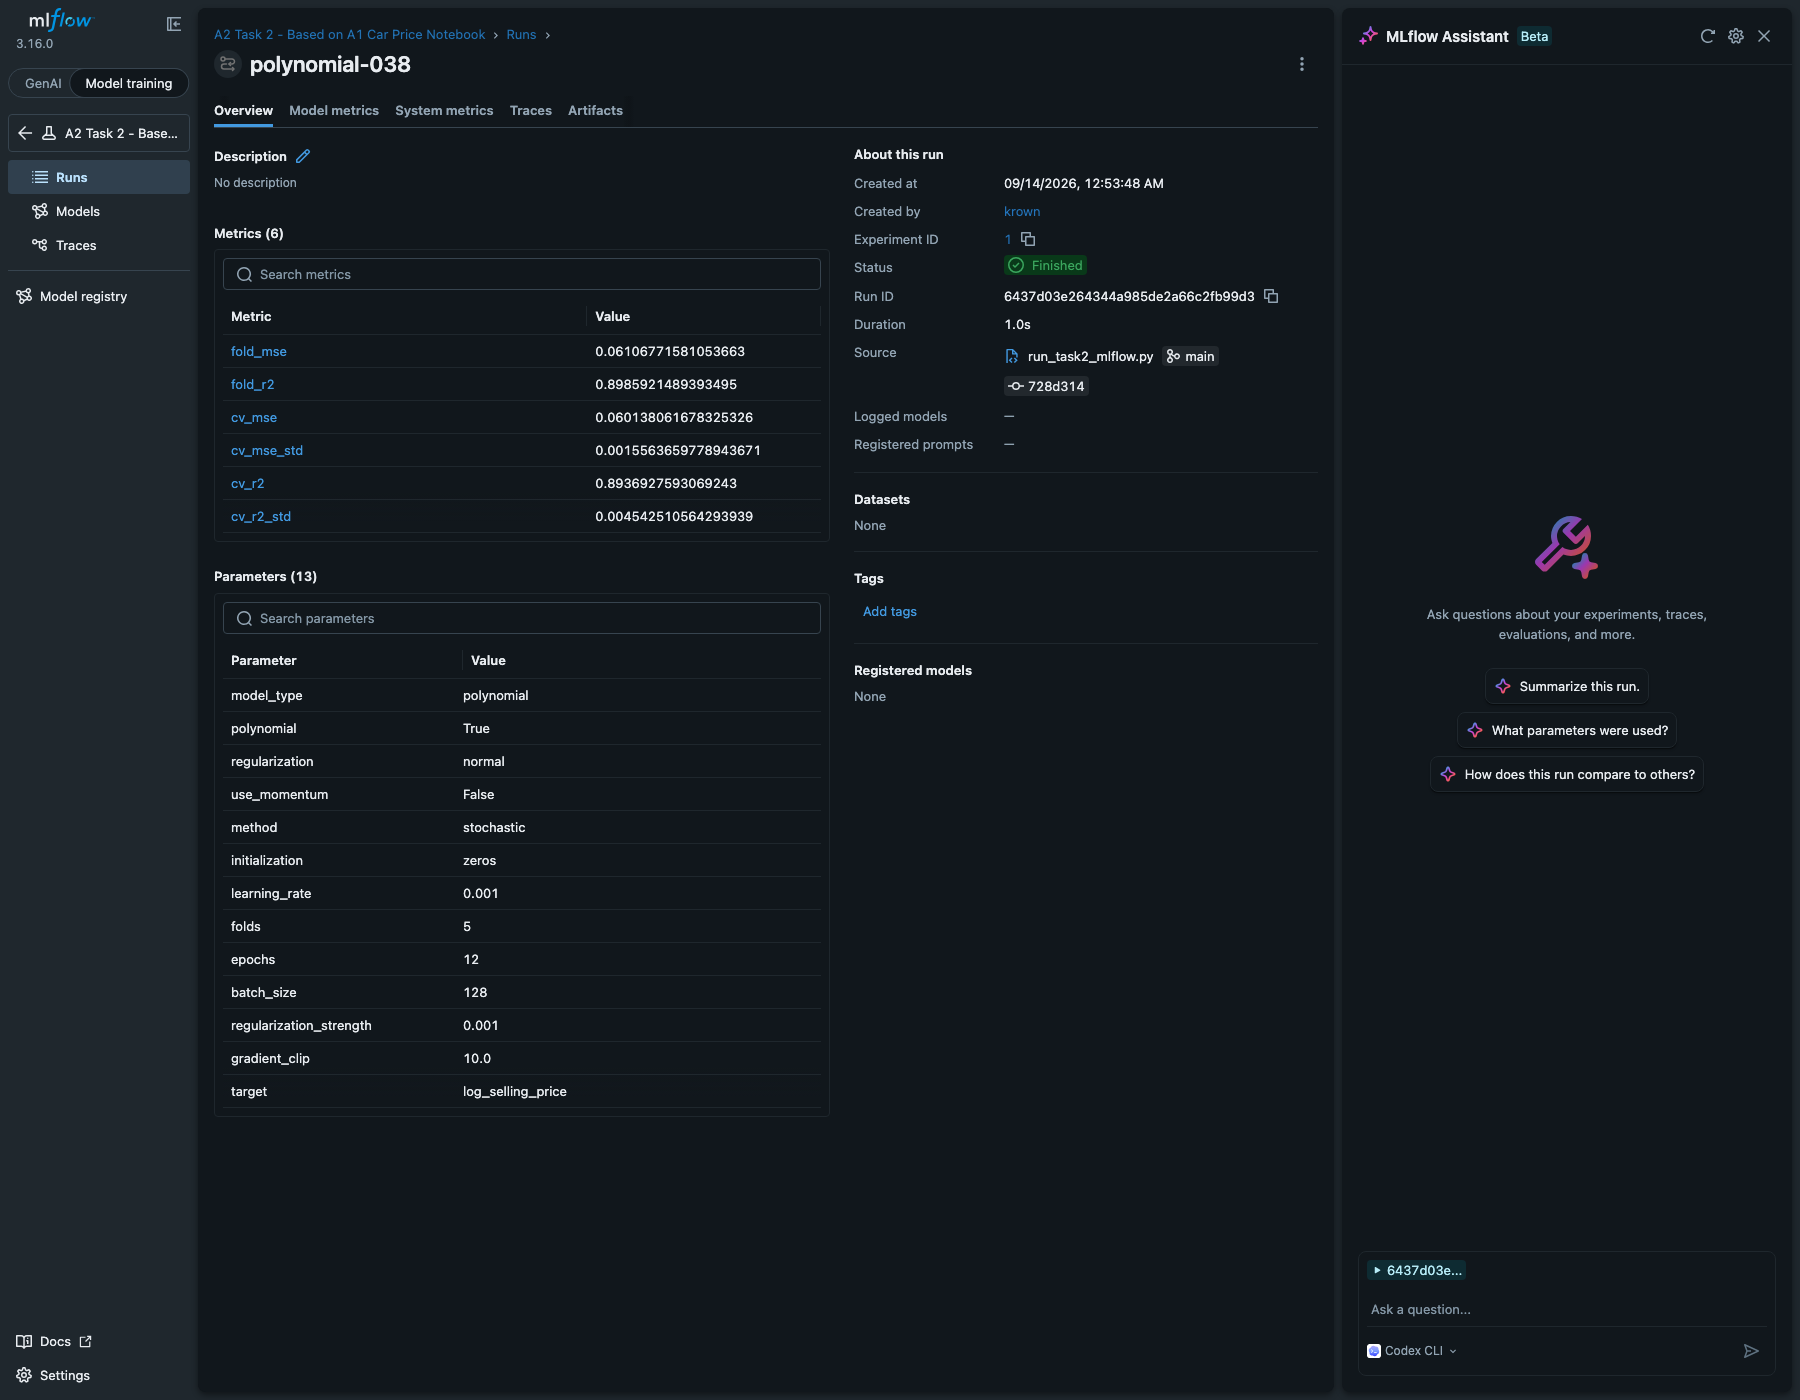

## Step 6 — Evaluate the selected model on the untouched test set

The configuration with the highest mean validation R² (using MSE as the tie-breaker) is refitted on all training rows for 60 epochs. The primary metrics remain on log selling price, matching Assignment 1. Rupee-scale metrics are also included for interpretation.

In [6]:
bundle = joblib.load('models/best_task2_model.joblib')
print('Best configuration:')
display(pd.Series(bundle['best_config'], name='value').to_frame())
print('Held-out test metrics:')
display(pd.Series(bundle['test_metrics'], name='value').to_frame())

Best configuration:


,value
model_type,polynomial
polynomial,True
regularization,normal
use_momentum,False
method,stochastic
initialization,zeros
learning_rate,0.001
cv_mse,0.060138
cv_mse_std,0.001556
cv_r2,0.893693


Held-out test metrics:


,value
test_mse_log,5.608228e-02
test_r2_log,8.969794e-01
test_mse_price,2.482435e+10
test_rmse_price,1.575575e+05
test_r2_price,8.831559e-01


## Step 7 — Plot feature importance

The Task 1 function ranks features by absolute coefficient magnitude while retaining each coefficient's sign. Numeric inputs are standardized, so their magnitudes are comparable. One-hot variables share a binary scale, but correlated variables may divide importance.

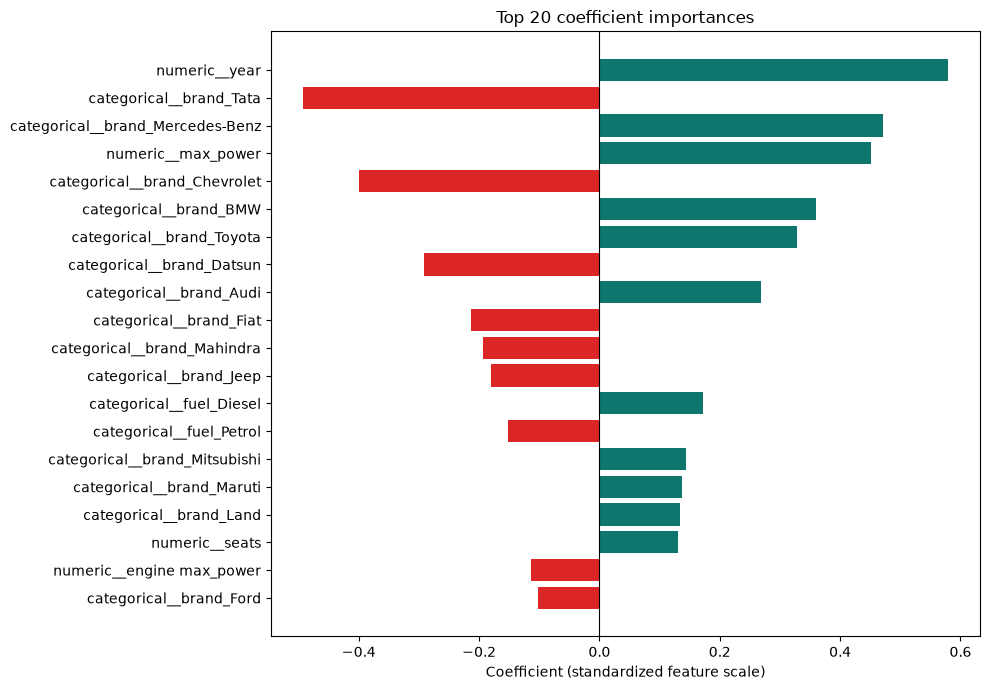

In [7]:
ax = bundle['model'].plot_feature_importance(
    bundle['feature_names'], top_n=20
)
plt.tight_layout()
plt.show()

## Step 8 — Short report and findings

The best individual configuration was **polynomial regression** using **stochastic gradient descent**, **zeros initialization**, a learning rate of **0.001**, and **no momentum**. Its five-fold mean log-MSE was **0.06014** and mean R² was **0.8937**. The fold-to-fold R² standard deviation was **0.0045**, indicating reasonably consistent validation performance.

After refitting, the untouched test set produced log-MSE **0.05608** and log-scale R² **0.8970**. On the original rupee scale, MSE was **24,824,350,542**, RMSE was **₹157,557**, and R² was **0.8832**.

Lasso had the strongest average R² among the four model families, but polynomial regression produced the best individual configuration. For non-polynomial models, stochastic gradient descent was strongest on average because it made many updates within the fixed 12-epoch budget. Polynomial models were sensitive to the largest stochastic learning rate; this instability reduced the overall stochastic average, making mini-batch the most robust method across all 144 runs. The learning rate 0.001 was strongest on average, zero initialization outperformed Xavier within the short budget, and momentum helped the winning configuration but did not improve every combination.

These results should not be interpreted as universal rankings. Batch gradient descent receives far fewer updates per epoch than stochastic learning, so a fixed epoch budget favors the latter. Only one regularization strength and polynomial degree were tested. Coefficients describe association rather than causation, and predictions may be less reliable for rare brands, luxury cars, and observations outside the training distribution.